In [45]:
import pandas as pd
import matplotlib.pyplot as plt

ratings = pd.read_parquet("../../data/Archive (1)/sample_user_rating_traj.parquet")
notes = pd.read_parquet("../../data/Archive (1)/sample_user_note_traj.parquet")
requests = pd.read_parquet("../../data/Archive (1)/sample_user_request_traj.parquet")

In [46]:
# First Part: What contribution types are most common for users to make in their first active month?
# For each user month, calculate each user's most common contribution type. 
# Plot the percent of users in each user month whose activity is dominated by each type. 

#  define label
ratings["type"] = "rating"
notes["type"] = "writing"
requests["type"] = "requesting"

# rename user id
ratings = ratings.rename(columns={"raterParticipantId": "user_id"})
notes = notes.rename(columns={"noteAuthorParticipantId": "user_id"})
requests = requests.rename(columns={"requesterParticipantId": "user_id"})

# keep needed columns
ratings_df = ratings[["user_id", "userMonth", "type"]]
notes_df = notes[["user_id", "userMonth", "type"]]
requests_df = requests[["user_id", "userMonth", "type"]]

# merge
df = pd.concat([ratings_df, notes_df, requests_df])

In [47]:
# Calculate the number of contributions made by each user per month.
counts = df.groupby(["user_id", "userMonth", "type"]).size().reset_index(name="count")
counts.head()

,user_id,userMonth,type,count
0,000AE77955227AE8D52CB70BA3FB647EBF198E2BBC385D...,0,requesting,1
1,000C7AC0F2AE15FB6C478257825D415D017580C0861125...,0,requesting,1
2,0014F9BA334FB10689F9D089BF47912797FBE78F01E3E3...,0,requesting,1
3,00167DE211B4D41B0E054EFD79A9771F2A2097A8285235...,0,requesting,1
4,00167DE211B4D41B0E054EFD79A9771F2A2097A8285235...,1,requesting,1


In [48]:
# Find the dominant type for each user.
dominant = counts.loc[counts.groupby(["user_id","userMonth"])["count"].idxmax()]
dominant.head()

,user_id,userMonth,type,count
0,000AE77955227AE8D52CB70BA3FB647EBF198E2BBC385D...,0,requesting,1
1,000C7AC0F2AE15FB6C478257825D415D017580C0861125...,0,requesting,1
2,0014F9BA334FB10689F9D089BF47912797FBE78F01E3E3...,0,requesting,1
3,00167DE211B4D41B0E054EFD79A9771F2A2097A8285235...,0,requesting,1
4,00167DE211B4D41B0E054EFD79A9771F2A2097A8285235...,1,requesting,1


In [49]:
# Calculate the number of users for each type per month.
month_counts = dominant.groupby(["userMonth","type"]).size().reset_index(name="users")
month_counts.head()

,userMonth,type,users
0,0,rating,5805
1,0,requesting,14187
2,0,writing,8
3,1,rating,2189
4,1,requesting,2085


In [50]:
# transfer 
total_users = month_counts.groupby("userMonth")["users"].transform("sum")
month_counts["percent"] = month_counts["users"] / total_users

plot_data = month_counts.pivot(index="userMonth", columns="type", values="percent")
plot_data.head()

type,rating,requesting,writing
userMonth,,,
0,0.290250,0.709350,0.000400
1,0.511568,0.487263,0.001168
2,0.613876,0.384953,0.001171
3,0.730915,0.267703,0.001382
4,0.805452,0.192308,0.002240


In [51]:
monthly = df.groupby(["userMonth","dominant"]).size().unstack(fill_value=0)

monthly_percent = monthly.div(monthly.sum(axis=1), axis=0)

monthly_percent.loc[:20].plot(
    kind="bar",
    stacked=True,
    figsize=(10,5)
)

plt.ylabel("Percent of Users")
plt.xlabel("User Month")
plt.title("Dominant Contribution Types Over Users Lifetimes")

plt.show()

KeyError: 'dominant'

In [ ]:
# Second part: Plot individual user trajectories
ratings_traj = ratings[["user_id","userMonth","notesRated"]].copy()
ratings_traj["type"] = "rating"
ratings_traj["count"] = ratings_traj["notesRated"]

notes_traj = notes[["user_id","userMonth","notesCreated"]].copy()
notes_traj["type"] = "writing"
notes_traj["count"] = notes_traj["notesCreated"]

requests_traj = requests[["user_id","userMonth","requestsMade"]].copy()
requests_traj["type"] = "requesting"
requests_traj["count"] = requests_traj["requestsMade"]

ratings_traj = ratings_traj[["user_id","userMonth","type","count"]]
notes_traj = notes_traj[["user_id","userMonth","type","count"]]
requests_traj = requests_traj[["user_id","userMonth","type","count"]]

traj_df = pd.concat([ratings_traj, notes_traj, requests_traj])

In [ ]:
df["dominant"] = df[["rating","writing","requesting"]].idxmax(axis=1)
sample_users = df["user_id"].drop_duplicates().sample(3)
sample_df = df[df["user_id"].isin(sample_users)]

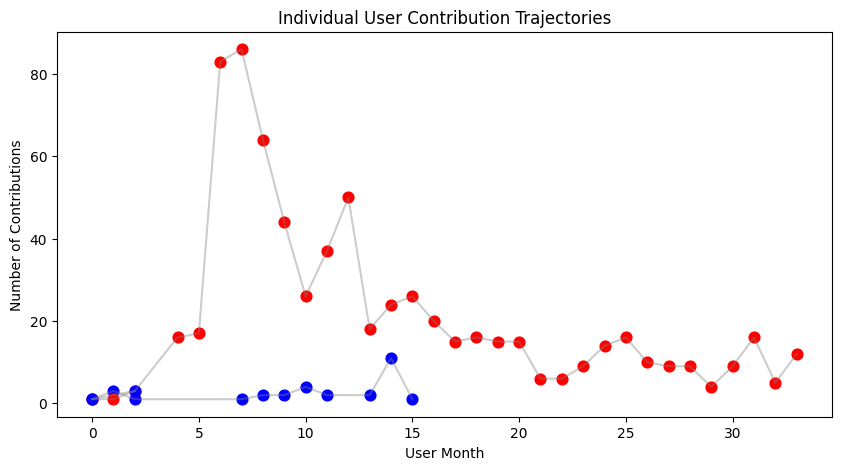

In [ ]:
colors = {
    "rating":"red",
    "writing":"green",
    "requesting":"blue"
}

plt.figure(figsize=(10,5))

for user in sample_users:
    
    user_data = sample_df[sample_df["user_id"] == user]
    
    plt.plot(
        user_data["userMonth"],
        user_data[["rating","writing","requesting"]].max(axis=1),
        color="gray",
        alpha=0.4
    )
    
    for _,row in user_data.iterrows():
        
        plt.scatter(
            row["userMonth"],
            max(row["rating"],row["writing"],row["requesting"]),
            color=colors[row["dominant"]],
            s=60
        )

plt.xlabel("User Month")
plt.ylabel("Number of Contributions")
plt.title("Individual User Contribution Trajectories")

plt.show()

In [ ]:
# double check ( no green part)
df["dominant"].value_counts()

dominant
rating        68978
requesting    23144
writing         159
Name: count, dtype: int64

In [ ]:
# # what was the average user month for users who rated a note?

# # Calculate the average user age for each of the three types of contributions.
# # rating
# # rating_age = (
#   #  df[df["rating"] > 0]
# reset_index()
# )

# rating_age["type"] = "rating"

# #writing
# writing_age = (
#     df[df["writing"] > 0]
#     .groupby("calendarMonth")["userMonth"]
#     .mean()
#     .reset_index()
# )

# writing_age["type"] = "writing"

# # requesting
# request_age = (
#     df[df["requesting"] > 0]
#     .groupby("calendarMonth")["userMonth"]
#     .mean()
#     .reset_index()
# )

# request_age["type"] = "requesting"

# # merge 3 results
# avg_age = pd.concat([rating_age, writing_age, request_age])